# Lab 9 - Support Vector Machine and Principal Component Analysis

Aim: To implement Support Vector Machine (SVM) for classification and Principal Component Analysis (PCA) for dimensionality reduction, and analyse their effectiveness using real world datasets.

## Part A: Support Vector Machine (SVM)

Aim: To implement the SVM classifier for a binary classification problem and evaluate its performance.

Dataset: UCI Breast Cancer Wisconsin (Diagnostic) dataset.

### 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

### 2. Load the dataset

The file wdbc.data has no header row, so the column names are added using the description in wdbc.names.

In [2]:
features = ['radius', 'texture', 'perimeter', 'area', 'smoothness', 'compactness',
            'concavity', 'concave_points', 'symmetry', 'fractal_dimension']

columns = ['id', 'diagnosis'] + [f'{stat}_{f}' for stat in ['mean', 'se', 'worst'] for f in features]

df = pd.read_csv('data/wdbc.data', header=None, names=columns)
df.head()

,id,diagnosis,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,...,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 32)

In [4]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

The dataset has 569 rows and 32 columns, which is id, diagnosis and 30 numeric features. Out of 569 patients 357 are benign and 212 are malignant, so benign cases are about 63 percent of the data. The classes are not equal but the imbalance is mild.

### 3. Preprocessing

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df = df.drop('id', axis=1)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

There are no missing values so no imputation is needed. The id column is dropped because it is only a patient number and has no predictive value. Diagnosis is encoded as 1 for malignant and 0 for benign so that sklearn can use it as the target.

### 4. Train test split (80:20)

In [7]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [8]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

The 80:20 split gives 455 training rows and 114 test rows. Stratify is used so both sets keep the same benign to malignant ratio. The features are on very different scales, for example mean_area goes above 2000 while mean_smoothness stays near 0.1, so StandardScaler is applied. SVM uses distances between points, so without scaling the large valued features would decide the margin on their own. The scaler is fitted only on the training data and then applied to the test data to avoid leakage.

### 5. SVM with linear kernel

In [9]:
svm_lin = SVC(kernel='linear', random_state=42)
svm_lin.fit(X_train_s, y_train)
y_pred_lin = svm_lin.predict(X_test_s)

print('Accuracy :', accuracy_score(y_test, y_pred_lin))
print('Precision:', precision_score(y_test, y_pred_lin))
print('Recall   :', recall_score(y_test, y_pred_lin))
print('F1 score :', f1_score(y_test, y_pred_lin))

Accuracy : 0.9649122807017544
Precision: 1.0
Recall   : 0.9047619047619048
F1 score : 0.95


[[72  0]
 [ 4 38]]


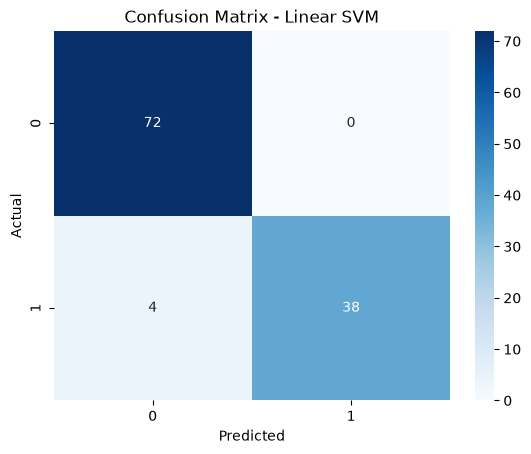

In [10]:
cm = confusion_matrix(y_test, y_pred_lin)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

In [11]:
print(classification_report(y_test, y_pred_lin, target_names=['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



The linear SVM gives 96.49 percent accuracy on the test set. Precision is 1.0 and recall is 0.905, so every case the model called malignant really was malignant, but it missed 4 malignant cases out of 42. The confusion matrix shows 72 benign correct, 38 malignant correct, 0 false positives and 4 false negatives. F1 score is 0.95. For a medical problem the 4 false negatives are the bigger worry, since telling a patient with cancer that they are fine is worse than a false alarm.

### 6. Hyperparameter tuning

In [12]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_s, y_train)

print('Best C:', grid.best_params_['C'])
print('Best CV accuracy:', grid.best_score_)

Best C: 0.01
Best CV accuracy: 0.9692307692307693


In [13]:
pd.DataFrame({'C': param_grid['C'], 'cv_accuracy': grid.cv_results_['mean_test_score']})

,C,cv_accuracy
0,0.01,0.969231
1,0.10,0.969231
2,1.00,0.962637
3,10.00,0.969231
4,100.00,0.958242


In [14]:
best_lin = grid.best_estimator_
y_pred_best = best_lin.predict(X_test_s)
print('Test accuracy after tuning:', accuracy_score(y_test, y_pred_best))

Test accuracy after tuning: 0.956140350877193


Grid search over C from 0.01 to 100 with 5 fold cross validation picks C = 0.01 with a CV accuracy of 96.92 percent. The CV accuracy hardly changes across the grid, it stays between 95.82 and 96.92 percent, so the model is not very sensitive to C on this dataset. Test accuracy after tuning is 95.61 percent, which is slightly lower than the default C = 1 model at 96.49 percent. This happens because the best C was chosen on the training folds and the test set is only 114 rows, so a difference of one sample changes accuracy by almost 1 percent. A small C means a wider margin and more regularisation, which is reasonable here since the data is already close to linearly separable after scaling.

### 7. Comparing different kernels

In [15]:
results = []
for k in ['linear', 'poly', 'rbf', 'sigmoid']:
    m = SVC(kernel=k, random_state=42)
    m.fit(X_train_s, y_train)
    p = m.predict(X_test_s)
    results.append({'kernel': k,
                    'accuracy': accuracy_score(y_test, p),
                    'precision': precision_score(y_test, p),
                    'recall': recall_score(y_test, p),
                    'f1': f1_score(y_test, p)})

kernel_df = pd.DataFrame(results)
kernel_df

,kernel,accuracy,precision,recall,f1
0,linear,0.964912,1.000000,0.904762,0.950000
1,poly,0.885965,1.000000,0.690476,0.816901
2,rbf,0.973684,1.000000,0.928571,0.962963
3,sigmoid,0.947368,0.973684,0.880952,0.925000


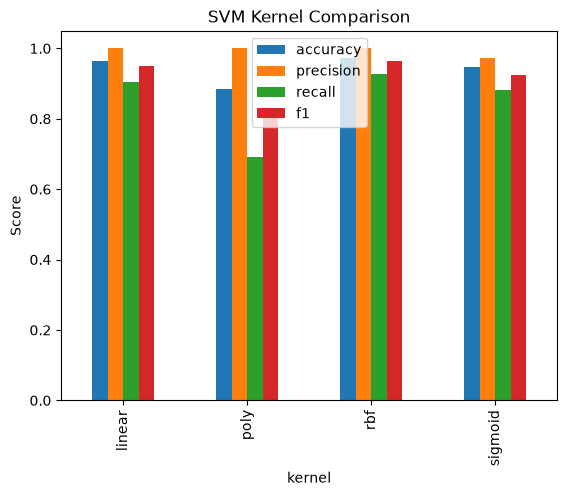

In [16]:
kernel_df.plot(x='kernel', y=['accuracy', 'precision', 'recall', 'f1'], kind='bar')
plt.ylabel('Score')
plt.title('SVM Kernel Comparison')
plt.ylim(0, 1.05)
plt.show()

The RBF kernel is the best with 97.37 percent accuracy and F1 of 0.963, followed by linear at 96.49 percent and sigmoid at 94.74 percent. The polynomial kernel is clearly the worst at 88.60 percent because its recall drops to 0.690, meaning it misses 13 malignant cases. Precision stays at 1.0 for linear, poly and rbf, so all three are conservative and only call a case malignant when they are confident. RBF works slightly better than linear because it can bend the boundary a little, but the gap is small which tells us the classes are almost linearly separable in the scaled 30 dimensional space.

### 8. Observations on Part A

1. SVM works well on this dataset, the best test accuracy is 97.37 percent with the RBF kernel.
2. Feature scaling matters a lot for SVM because the kernel is based on distances.
3. All the good kernels have precision 1.0 but recall below 1.0, so the errors are all false negatives.
4. Tuning C did not help much here, the linear boundary was already close to the best possible.
5. The polynomial kernel with default degree 3 overfits the training data and generalises worst.

## Part B: Principal Component Analysis (PCA)

Aim: To implement PCA for dimensionality reduction and analyse the variance retained by the principal components.

Dataset: UCI Wine dataset.

### 1. Load the dataset and standardize the features

In [17]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA

wine = load_wine()
wine_df = pd.DataFrame(wine.data, columns=wine.feature_names)
wine_df['class'] = wine.target
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [18]:
print(wine_df.shape)
print(wine_df['class'].value_counts().sort_index())

(178, 14)
class
0    59
1    71
2    48
Name: count, dtype: int64


In [19]:
wine_df.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


The wine dataset has 178 rows and 13 features plus the class column. The three classes have 59, 71 and 48 samples, so it is fairly balanced. Looking at the describe output the feature scales are very different, proline ranges from 278 to 1680 while hue stays between 0.48 and 1.71. PCA works on variance, so without standardisation proline alone would dominate every component.

In [20]:
Xw = wine_df.drop('class', axis=1)
yw = wine_df['class']

Xw_scaled = StandardScaler().fit_transform(Xw)
print(Xw_scaled.mean(axis=0).round(3)[:5])
print(Xw_scaled.std(axis=0).round(3)[:5])

[-0. -0. -0. -0. -0.]
[1. 1. 1. 1. 1.]


After StandardScaler every feature has mean 0 and standard deviation 1, which the printed values confirm. Now all 13 features contribute to the variance on equal terms.

### 2. Apply PCA with 2 components

In [21]:
pca2 = PCA(n_components=2)
Xw_pca2 = pca2.fit_transform(Xw_scaled)
print(Xw_pca2.shape)

(178, 2)


### 3. Explained variance ratio

In [22]:
print('Explained variance ratio:', pca2.explained_variance_ratio_)
print('Total variance retained by 2 components:', pca2.explained_variance_ratio_.sum())

Explained variance ratio: [0.36198848 0.1920749 ]
Total variance retained by 2 components: 0.5540633835693527


PC1 explains 36.20 percent of the variance and PC2 explains 19.21 percent. Together the two components keep 55.41 percent of the total variance, so almost 45 percent of the information is lost when we go from 13 features down to 2.

### 4. Cumulative explained variance

In [23]:
pca_full = PCA()
pca_full.fit(Xw_scaled)

evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

var_table = pd.DataFrame({'component': range(1, len(evr) + 1),
                          'explained_variance_ratio': evr,
                          'cumulative': cum})
var_table

,component,explained_variance_ratio,cumulative
0,1,0.361988,0.361988
1,2,0.192075,0.554063
2,3,0.111236,0.665300
3,4,0.070690,0.735990
4,5,0.065633,0.801623
5,6,0.049358,0.850981
6,7,0.042387,0.893368
7,8,0.026807,0.920175
8,9,0.022222,0.942397
9,10,0.019300,0.961697


In [24]:
n95 = np.argmax(cum >= 0.95) + 1
print('Minimum components to retain 95% variance:', n95)
print('Variance retained by those components:', cum[n95 - 1])

Minimum components to retain 95% variance: 10
Variance retained by those components: 0.9616971684450644


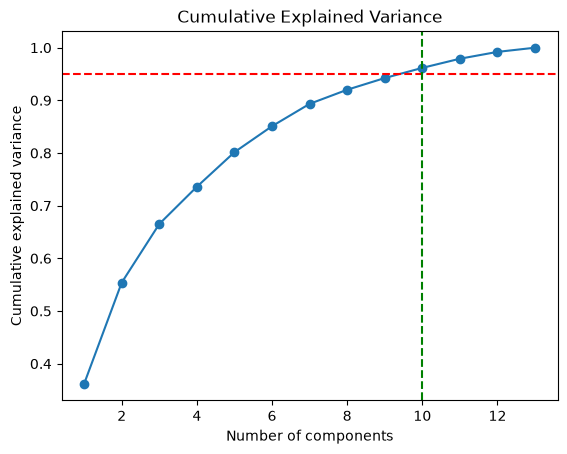

In [25]:
plt.plot(range(1, len(cum) + 1), cum, marker='o')
plt.axhline(0.95, color='red', linestyle='--')
plt.axvline(n95, color='green', linestyle='--')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('Cumulative Explained Variance')
plt.show()

The cumulative variance table shows that no single component dominates, the values fall slowly from 0.362 to 0.008. It takes 10 components to cross 95 percent, and those 10 components retain 96.17 percent of the variance. So on this dataset PCA does not compress much if we insist on keeping 95 percent, we only drop from 13 features to 10. This tells us the 13 wine features are not very correlated with each other, each one carries some of its own information.

### 5. Visualising the transformed data

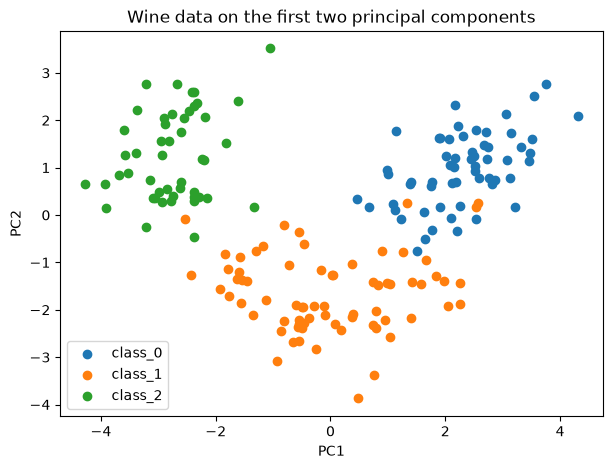

In [26]:
plt.figure(figsize=(7, 5))
for c in sorted(yw.unique()):
    plt.scatter(Xw_pca2[yw == c, 0], Xw_pca2[yw == c, 1], label=wine.target_names[c])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Wine data on the first two principal components')
plt.show()

Even though the two components keep only 55 percent of the variance, the scatter plot separates the three wine classes quite well. Class 0 sits on the right, class 2 sits on the left and class 1 sits in the middle, mostly along PC1. There is a small overlap between class 1 and the other two near the centre. So the directions of largest variance happen to line up with the class differences here, but that is luck and not something PCA is designed to do, because PCA never sees the labels.

### 6. Comparing original and transformed datasets

In [27]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

t0 = time.time()
acc_full = cross_val_score(LogisticRegression(max_iter=5000), Xw_scaled, yw, cv=5).mean()
t_full = time.time() - t0

t0 = time.time()
acc_pca = cross_val_score(LogisticRegression(max_iter=5000), Xw_pca2, yw, cv=5).mean()
t_pca = time.time() - t0

pd.DataFrame({'dataset': ['original', 'PCA (2 components)'],
              'n_features': [Xw_scaled.shape[1], Xw_pca2.shape[1]],
              'variance_retained': [1.0, pca2.explained_variance_ratio_.sum()],
              'cv_accuracy': [acc_full, acc_pca],
              'fit_time_sec': [t_full, t_pca]})

,dataset,n_features,variance_retained,cv_accuracy,fit_time_sec
0,original,13,1.000000,0.988889,0.019733
1,PCA (2 components),2,0.554063,0.955238,0.008119


Number of features drops from 13 to 2. Information retained drops from 100 percent to 55.41 percent. Cross validated logistic regression accuracy falls from 98.89 percent to 95.52 percent, so we lose about 3.4 percentage points of accuracy. Fit time falls from about 0.0197 seconds to about 0.0081 seconds, which is roughly 2.4 times faster. On a dataset this small the time saving does not matter, but on a dataset with thousands of features the same idea saves a lot of computation. The trade off is that we give up a little accuracy and all interpretability of the original features in exchange for speed and the ability to plot the data.

### 7. Significance of the first two components

In [28]:
loadings = pd.DataFrame(pca2.components_.T, columns=['PC1', 'PC2'], index=wine.feature_names)
loadings.round(3)

,PC1,PC2
alcohol,0.144,0.484
malic_acid,-0.245,0.225
ash,-0.002,0.316
alcalinity_of_ash,-0.239,-0.011
magnesium,0.142,0.300
total_phenols,0.395,0.065
flavanoids,0.423,-0.003
nonflavanoid_phenols,-0.299,0.029
proanthocyanins,0.313,0.039
color_intensity,-0.089,0.530


In [29]:
print('Top features on PC1:')
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print()
print('Top features on PC2:')
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

Top features on PC1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top features on PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


PC1 is loaded most on flavanoids (0.423), total_phenols (0.395), od280/od315 (0.376) and proanthocyanins (0.313), all with the same sign. These are all phenol related chemistry, so PC1 can be read as an overall phenol content axis, wines high on PC1 are rich in phenols and flavanoids.

PC2 is loaded most on color_intensity (0.530), alcohol (0.484), proline (0.365) and ash (0.316). These describe how strong and heavy the wine is, so PC2 can be read as a body and colour strength axis.

Together they say the two biggest sources of variation between wines in this data are how phenolic they are and how strong and dark they are.

### 8. Advantages, limitations and applications of PCA

Advantages
1. Reduces the number of features, so models train faster and need less memory.
2. Removes correlation between features, since the components are orthogonal.
3. Lets high dimensional data be plotted in 2D or 3D for visual inspection.
4. Can reduce overfitting by dropping the low variance directions which are often noise.

Limitations
1. The components are linear mixtures of all the original features, so they are hard to interpret.
2. It is unsupervised, it maximises variance and not class separation, so a high variance direction is not always a useful direction.
3. It only finds linear structure, a curved manifold is not captured.
4. It needs the features to be standardised first, otherwise the largest scaled feature takes over.
5. Some information is always lost, here 44.59 percent with 2 components.

Applications
Image compression, face recognition using eigenfaces, gene expression analysis, noise reduction in signals, and as a preprocessing step before clustering or classification when the number of features is large.

## Extra credit: Linear Discriminant Analysis (LDA)

Apply LDA to the wine dataset, reduce it to two linear discriminants, visualise the result and compare with PCA.

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
Xw_lda = lda.fit_transform(Xw_scaled, yw)
print(Xw_lda.shape)
print('Explained variance ratio:', lda.explained_variance_ratio_)

(178, 2)
Explained variance ratio: [0.68747889 0.31252111]


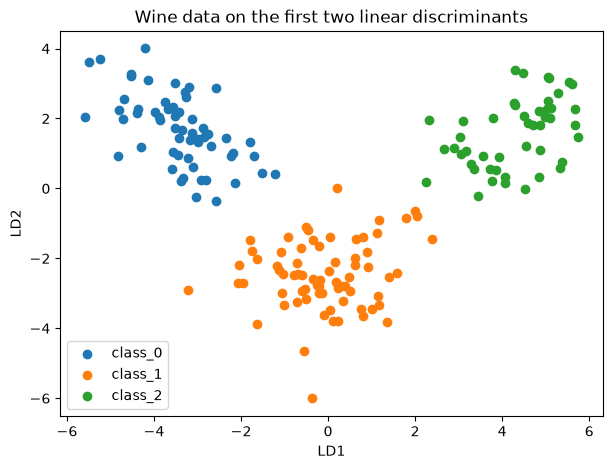

In [31]:
plt.figure(figsize=(7, 5))
for c in sorted(yw.unique()):
    plt.scatter(Xw_lda[yw == c, 0], Xw_lda[yw == c, 1], label=wine.target_names[c])
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.title('Wine data on the first two linear discriminants')
plt.show()

In [32]:
acc_lda = cross_val_score(LogisticRegression(max_iter=5000), Xw_lda, yw, cv=5).mean()

pd.DataFrame({'method': ['PCA (2 components)', 'LDA (2 discriminants)'],
              'supervised': ['No', 'Yes'],
              'cv_accuracy': [acc_pca, acc_lda]})

,method,supervised,cv_accuracy
0,PCA (2 components),No,0.955238
1,LDA (2 discriminants),Yes,1.000000


LDA reduces the 13 features to 2 linear discriminants. LD1 accounts for 68.75 percent and LD2 for 31.25 percent of the between class variance. In the scatter plot the three classes form three clearly separated groups with almost no overlap, which is much cleaner than the PCA plot.

Cross validated logistic regression accuracy on the LDA features is 100 percent compared to 95.52 percent on the PCA features. LDA does better because it is supervised, it uses the class labels and looks for the directions that push the class means apart while keeping each class tight. PCA never sees the labels and only looks for the directions of largest total variance.

The limit of LDA is that it can produce at most number of classes minus 1 components, so with 3 wine classes we can never get more than 2 discriminants. PCA has no such limit. So LDA is the better choice when the goal is classification and labels are available, and PCA is the better choice when there are no labels or when we want a general purpose compression of the data.

## Conclusion

In this lab SVM and PCA were implemented on two real world datasets.

In Part A the SVM classifier was trained on the Breast Cancer Wisconsin dataset after scaling and an 80:20 split. The linear kernel gave 96.49 percent test accuracy with precision 1.0 and recall 0.905. Tuning C by 5 fold grid search picked C = 0.01 with 96.92 percent CV accuracy, and comparing kernels showed RBF was the best at 97.37 percent while the polynomial kernel was the worst at 88.60 percent. The main takeaway is that SVM needs scaled features and that all the remaining errors on this dataset were false negatives.

In Part B PCA was applied to the Wine dataset after standardisation. Two components retained 55.41 percent of the variance and still separated the three classes well in the scatter plot, but 10 components were needed to reach 95 percent variance, which shows the features are not strongly correlated. Reducing to 2 components cost about 3.4 percentage points of classification accuracy but made the model about 2.4 times faster to fit.

The extra credit task showed that LDA, being supervised, gave a cleaner separation and 100 percent cross validated accuracy on the same data with the same 2 dimensions. Overall the lab shows how a supervised method like SVM and an unsupervised method like PCA solve different problems, and that when labels are available a supervised reduction like LDA can beat PCA at preparing data for classification.